In [1]:
# =============================================================
# ERA COMPARISON PROJECT - Notebook 2: Era 1 Rule-Based Strategies
# 
# Era 1 Philosophy: Human experts write explicit rules based on
# market observations. The computer just executes those rules.
# No learning, no adaptation - pure logic.
#
# We implement two classic strategies:
# 1. Moving Average Crossover - a "trend following" strategy
# 2. RSI - a "mean reversion" strategy (opposite logic)
# =============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# We focus on AAPL for all three eras to keep comparisons fair
# Same stock, same time period, different methods
ticker = 'AAPL'
data = yf.download(ticker, start='2014-01-01', end='2024-01-01')

# squeeze() converts a single-column DataFrame into a simpler Series
prices = data['Close'].squeeze()
print(f"Total trading days: {len(prices)}")

[*********************100%***********************]  1 of 1 completed

Total trading days: 2516


In [2]:
# =============================================================
# BACKTESTING FRAMEWORK
#
# A backtest simulates: "if I had used this strategy historically,
# what would my portfolio look like today?"
#
# Key assumption: we use signal.shift(1) to avoid "lookahead bias"
# This means we only act on yesterday's signal, not today's.
# In real trading, you cannot know today's closing price before
# the market closes - so we must simulate this constraint.
#
# Output metrics:
# - Total Return: overall % gain from start to end
# - Annual Return: % gain per year (accounts for different periods)
# - Max Drawdown: worst peak-to-trough loss (measures pain)
# - Sharpe Ratio: return per unit of risk taken
#   Formula: sqrt(252) * mean(excess_returns) / std(excess_returns)
#   Higher is better. Above 1.0 is generally considered good.
# =============================================================

def backtest(prices, signal, initial_capital=10000):
    """
    Simulate a trading strategy and compute performance metrics.
    
    Parameters:
        prices: daily closing prices (pandas Series)
        signal: 1 = hold position, 0 = stay in cash (pandas Series)
        initial_capital: starting portfolio value in USD
    
    Returns:
        results: dictionary of performance metrics
        portfolio: daily portfolio value (pandas Series)
        buy_and_hold: benchmark portfolio if we just held the stock
    """
    
    # Daily percentage change in price
    daily_returns = prices.pct_change()
    
    # Strategy return on day t = signal from day t-1 * return on day t
    # shift(1) is critical: we decide based on yesterday's signal,
    # then earn today's return
    strategy_returns = signal.shift(1) * daily_returns
    
    # Compound the returns day by day to get portfolio value
    # (1 + r1) * (1 + r2) * ... gives cumulative growth
    portfolio = initial_capital * (1 + strategy_returns).cumprod()
    
    # Benchmark: what if we just bought and held the stock?
    buy_and_hold = initial_capital * (1 + daily_returns).cumprod()
    
    # --- Performance Metrics ---
    
    # Total return: how much did we make in total?
    total_return = (portfolio.iloc[-1] / initial_capital - 1) * 100
    
    # Annualized return: normalize for time period length
    # Formula: (final_value / initial_value)^(1/years) - 1
    n_years = len(prices) / 252
    annual_return = ((portfolio.iloc[-1] / initial_capital) ** (1/n_years) - 1) * 100
    
    # Maximum drawdown: largest drop from any peak to subsequent trough
    # This tells us: "what's the worst loss an investor would have felt?"
    rolling_max = portfolio.cummax()  # highest value seen so far
    drawdown = (portfolio - rolling_max) / rolling_max
    max_drawdown = drawdown.min() * 100
    
    # Sharpe Ratio: risk-adjusted return
    # We subtract the risk-free rate (2% annual = 0.02/252 daily)
    # to measure how much extra return we earn per unit of risk
    excess_returns = strategy_returns - 0.02/252
    sharpe = np.sqrt(252) * excess_returns.mean() / excess_returns.std()
    
    results = {
        'Total Return (%)': round(total_return, 2),
        'Annual Return (%)': round(annual_return, 2),
        'Max Drawdown (%)': round(max_drawdown, 2),
        'Sharpe Ratio': round(sharpe, 2)
    }
    
    return results, portfolio, buy_and_hold

In [3]:
# =============================================================
# STRATEGY 1: MOVING AVERAGE CROSSOVER
#
# Logic: When short-term momentum is stronger than long-term trend,
# the market is likely in an upswing - buy in.
# When short-term drops below long-term - get out.
#
# This is a "trend following" strategy:
# it tries to catch and ride existing trends.
#
# Weakness: In sideways markets, the two lines cross frequently
# generating many false signals - known as "whipsawing"
# =============================================================

def ma_crossover_signal(prices, short_window=20, long_window=50):
    """
    Generate buy/sell signals using moving average crossover.
    
    Short MA (20 days) crossing above Long MA (50 days) = bullish signal
    Short MA crossing below Long MA = exit position
    """
    # Rolling mean over the last N days
    short_ma = prices.rolling(window=short_window).mean()
    long_ma = prices.rolling(window=long_window).mean()
    
    # Signal = 1 (hold) when short MA is above long MA, else 0 (cash)
    # astype(int) converts True/False to 1/0
    signal = (short_ma > long_ma).astype(int)
    
    return signal, short_ma, long_ma

# Generate signals and run backtest
signal_ma, short_ma, long_ma = ma_crossover_signal(prices)
results_ma, portfolio_ma, buy_and_hold = backtest(prices, signal_ma)

print("=== Era 1: Moving Average Crossover ===")
for k, v in results_ma.items():
    print(f"{k}: {v}")

=== Era 1: Moving Average Crossover ===
Total Return (%): 278.94
Annual Return (%): 14.27
Max Drawdown (%): -29.09
Sharpe Ratio: 0.67


In [4]:
# =============================================================
# STRATEGY 2: RSI (Relative Strength Index)
#
# RSI measures how fast and how much a stock has moved recently.
# It outputs a value between 0 and 100.
#
# The logic is "mean reversion": what goes up must come down.
# - RSI > 70: stock rose too fast, likely to pull back -> SELL
# - RSI < 30: stock fell too fast, likely to bounce -> BUY
#
# This is the OPPOSITE philosophy to MA Crossover:
# MA follows trends, RSI bets against them.
#
# Weakness: In a strong bull market (like AAPL 2020-2021),
# RSI stays overbought for months. Selling early means
# missing most of the gains.
# =============================================================

def compute_rsi(prices, window=14):
    """
    Compute the Relative Strength Index (RSI).
    
    RSI = 100 - (100 / (1 + RS))
    where RS = average gain / average loss over the window period
    """
    delta = prices.diff()  # daily price changes
    
    # Separate gains (positive days) and losses (negative days)
    gain = delta.clip(lower=0)   # keep only positive changes
    loss = -delta.clip(upper=0)  # keep only negative changes (make positive)
    
    # Average gain and loss over the window
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    
    rs = avg_gain / avg_loss  # Relative Strength
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

def rsi_signal(prices, window=14, oversold=30, overbought=70):
    """
    Generate trading signals based on RSI thresholds.
    Buy when oversold (RSI < 30), sell when overbought (RSI > 70).
    """
    rsi = compute_rsi(prices, window)
    signal = pd.Series(index=prices.index, dtype=float)
    
    # We track position state: are we currently holding (1) or in cash (0)?
    position = 0
    for i in range(len(rsi)):
        if rsi.iloc[i] < oversold:
            position = 1   # oversold: buy in
        elif rsi.iloc[i] > overbought:
            position = 0   # overbought: exit
        signal.iloc[i] = position
    
    return signal, rsi

# Generate signals and run backtest
signal_rsi, rsi = rsi_signal(prices)
results_rsi, portfolio_rsi, _ = backtest(prices, signal_rsi)

print("=== Era 1: RSI Strategy ===")
for k, v in results_rsi.items():
    print(f"{k}: {v}")

=== Era 1: RSI Strategy ===
Total Return (%): 89.58
Annual Return (%): 6.62
Max Drawdown (%): -29.94
Sharpe Ratio: 0.31


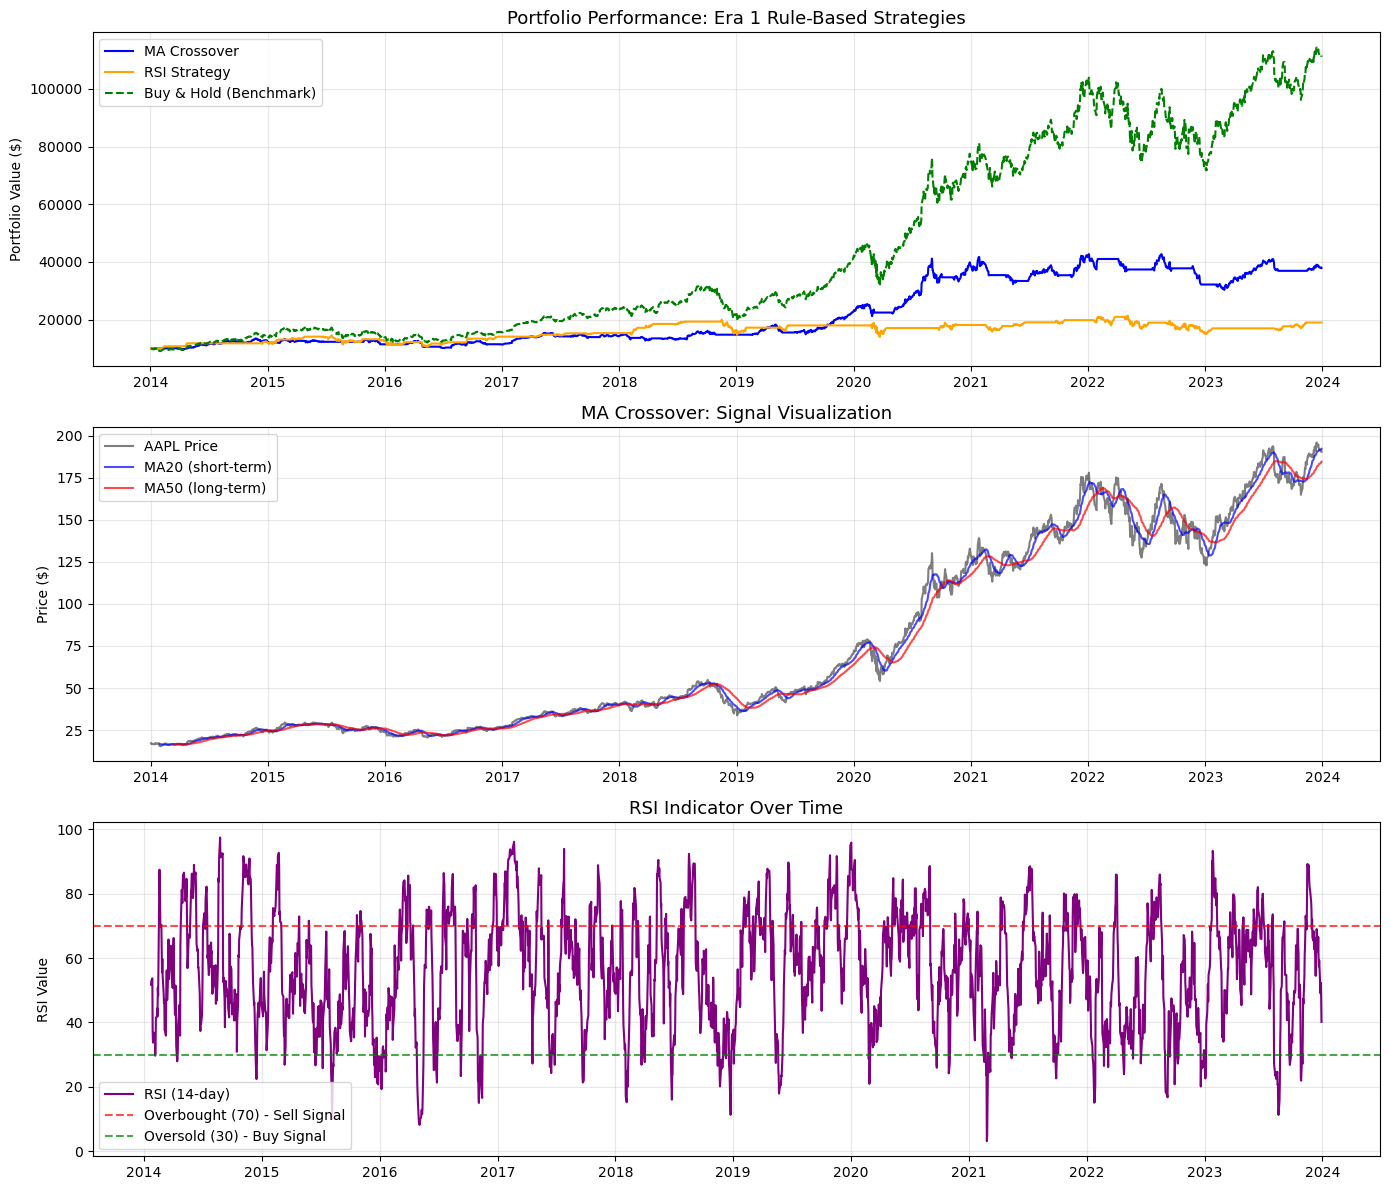

In [5]:
# =============================================================
# VISUALIZATION: Three-panel comparison chart
#
# Panel 1: Portfolio value over time
#   Shows how each strategy's account grew (or didn't)
#   compared to simply holding the stock
#
# Panel 2: MA Crossover signals on price chart
#   Shows the two moving average lines on top of actual price
#   You can visually see when crossovers happen
#
# Panel 3: RSI indicator over time
#   Shows the RSI line oscillating between 0-100
#   Red dashed line = overbought threshold (70)
#   Green dashed line = oversold threshold (30)
# =============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# --- Panel 1: Portfolio Performance ---
axes[0].plot(portfolio_ma.index, portfolio_ma,
             label='MA Crossover', color='blue')
axes[0].plot(portfolio_rsi.index, portfolio_rsi,
             label='RSI Strategy', color='orange')
axes[0].plot(buy_and_hold.index, buy_and_hold,
             label='Buy & Hold (Benchmark)', color='green', linestyle='--')
axes[0].set_title('Portfolio Performance: Era 1 Rule-Based Strategies',
                  fontsize=13)
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Panel 2: MA Crossover Signals ---
axes[1].plot(prices.index, prices,
             label='AAPL Price', color='black', alpha=0.5)
axes[1].plot(short_ma.index, short_ma,
             label='MA20 (short-term)', color='blue', alpha=0.7)
axes[1].plot(long_ma.index, long_ma,
             label='MA50 (long-term)', color='red', alpha=0.7)
axes[1].set_title('MA Crossover: Signal Visualization', fontsize=13)
axes[1].set_ylabel('Price ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Panel 3: RSI Indicator ---
axes[2].plot(rsi.index, rsi, color='purple', label='RSI (14-day)')
axes[2].axhline(y=70, color='red', linestyle='--',
                alpha=0.7, label='Overbought (70) - Sell Signal')
axes[2].axhline(y=30, color='green', linestyle='--',
                alpha=0.7, label='Oversold (30) - Buy Signal')
axes[2].set_title('RSI Indicator Over Time', fontsize=13)
axes[2].set_ylabel('RSI Value')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/03_era1_rule_based.png', dpi=150)
plt.show()